Python EDA (Retail Profit Leakage Analysis)

In [1]:
#Importing Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [2]:
df=pd.read_csv("../../dataset/Clean_superstore.csv")
print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156  2016-11-08  2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156  2016-11-08  2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688  2016-06-12  2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966  2015-10-11  2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966  2015-10-11  2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Sub-Category                                       Product Name     Sales  \
0    Bookcase

Total Business Overview

In [3]:
#Total Sales and Profit
print(df["Sales"].sum())
print(df["Profit"].sum())
#Average Profit Margin
avg_profit = df["Profit Margin"].mean()
print("Average Profit Margin:", avg_profit)

2297200.8603000003
286397.0217
Average Profit Margin: 0.12031392972104457


Sales By Category

In [4]:
sales_by_category=df.groupby("Category")["Sales"].sum()
print(sales_by_category)

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64


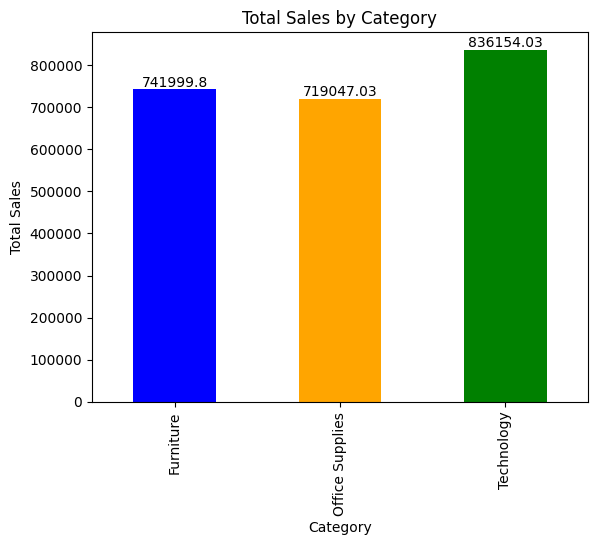

In [5]:
ax=sales_by_category.plot(kind="bar", color=["blue", "orange", "green"])
for i,v in enumerate(sales_by_category):
    ax.text(i,v,str(round(v,2)),ha="center", va="bottom")
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()



Profit by Category

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64


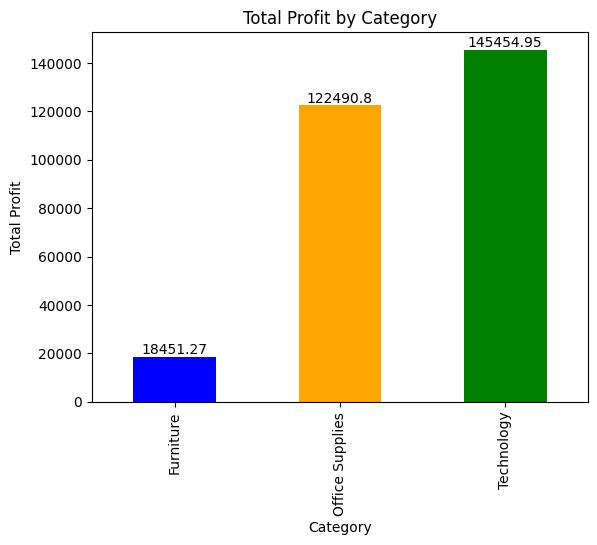

In [6]:
profit_by_category=df.groupby("Category")["Profit"].sum()
print(profit_by_category)
ax=profit_by_category.plot(kind="bar", color=["blue", "orange", "green"])
for i,v in enumerate(profit_by_category):
    ax.text(i,v,str(round(v,2)),ha="center", va="bottom")       
plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.show()      


Profit By Sub-Category

In [7]:
Profit_by_sub_category=df.groupby("Sub-Category")["Profit"].sum().sort_values(ascending=False)
print(Profit_by_sub_category)

Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Chairs         26590.1663
Storage        21278.8264
Appliances     18138.0054
Furnishings    13059.1436
Envelopes       6964.1767
Art             6527.7870
Labels          5546.2540
Machines        3384.7569
Fasteners        949.5182
Supplies       -1189.0995
Bookcases      -3472.5560
Tables        -17725.4811
Name: Profit, dtype: float64


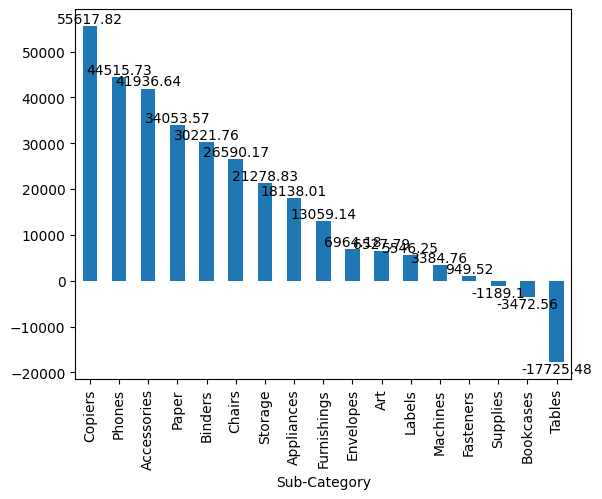

In [8]:
ax=Profit_by_sub_category.plot(kind="bar")
for i,v in enumerate(Profit_by_sub_category):
    va="bottom" if v>=0 else "top"
    ax.text(i,v,str(round(v,2)),ha="center",va=va)


Sales Trend Analysis

In [9]:
Monthly_sales=df.groupby("Month")["Sales"].sum()
print(Monthly_sales)

Month
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: Sales, dtype: float64
